In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

username = "root"
password = "2003"
host = "localhost"
port = "3306"
database = "cart2insights"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (4, 3)

# Load feature tables from earlier
orders_features = pd.read_csv("../data/features/orders_features.csv")
customer_features = pd.read_csv("../data/features/customer_features.csv")
seller_features = pd.read_csv("../data/features/seller_features.csv")

with engine.connect() as conn:
    print("Connected successfully!")

Connected successfully!


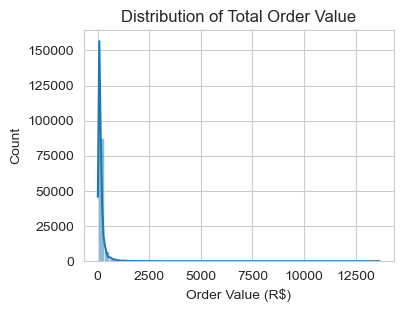

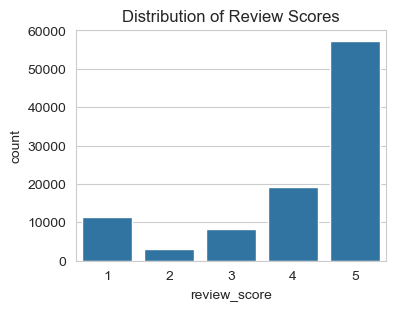

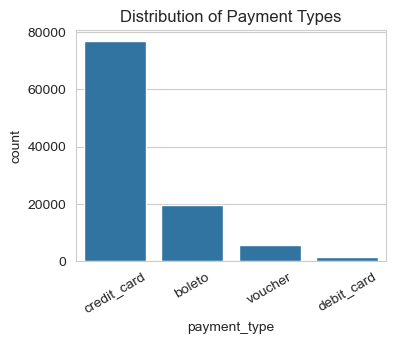

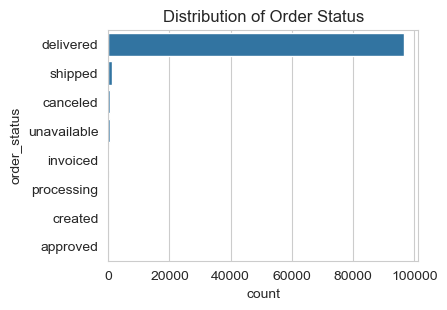

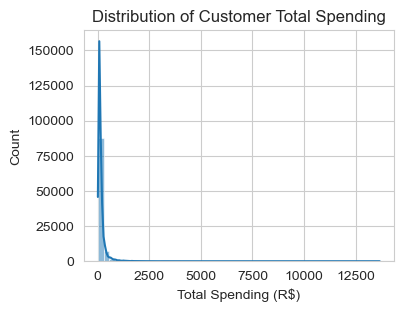

In [10]:
# Order value distribution
plt.figure()
sns.histplot(orders_features["total_order_value"], bins=50, kde=True)
plt.title("Distribution of Total Order Value")
plt.xlabel("Order Value (R$)")
plt.show()

# Review score distribution
reviews = pd.read_sql("SELECT review_score FROM order_reviews", con=engine)
plt.figure()
sns.countplot(data=reviews, x="review_score")
plt.title("Distribution of Review Scores")
plt.show()

# Payment type distribution
payments = pd.read_sql("SELECT payment_type FROM order_payments", con=engine)
plt.figure()
sns.countplot(data=payments, x="payment_type", order=payments["payment_type"].value_counts().index)
plt.title("Distribution of Payment Types")
plt.xticks(rotation=30)
plt.show()

# Order status distribution
statuses = pd.read_sql("SELECT order_status FROM orders", con=engine)
plt.figure()
sns.countplot(data=statuses, y="order_status", order=statuses["order_status"].value_counts().index)
plt.title("Distribution of Order Status")
plt.show()

# Customer spending distribution
plt.figure()
sns.histplot(customer_features["customer_total_spending"], bins=50, kde=True)
plt.title("Distribution of Customer Total Spending")
plt.xlabel("Total Spending (R$)")
plt.show()

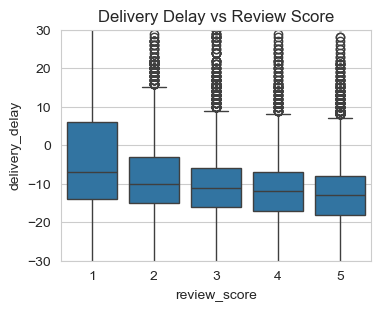

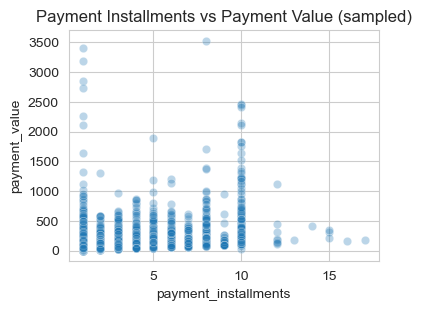

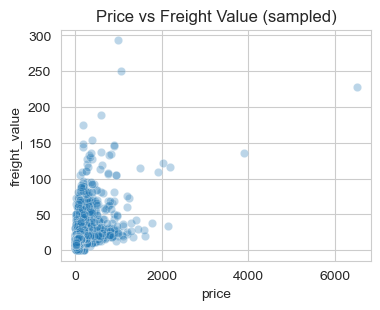

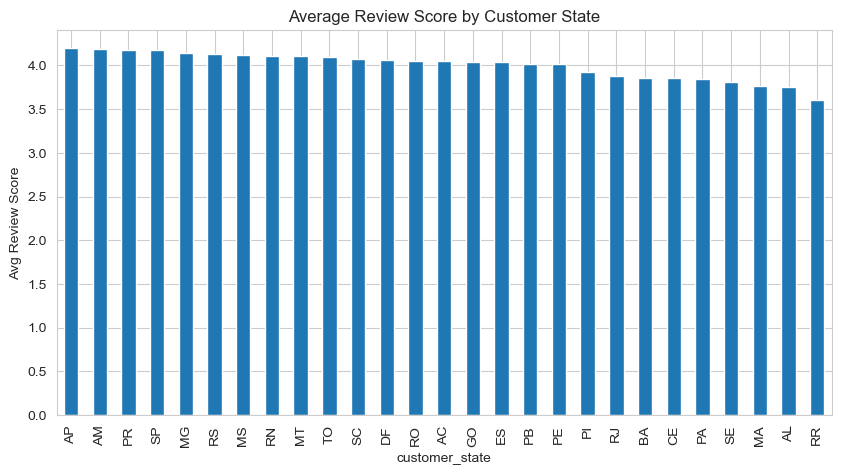

In [11]:
# 1. Delivery delay vs review score
merged = pd.read_sql("""
    SELECT o.order_id, o.order_delivered_customer_date, o.order_estimated_delivery_date,
           r.review_score
    FROM orders o
    JOIN order_reviews r ON o.order_id = r.order_id
    WHERE o.order_delivered_customer_date IS NOT NULL
""", con=engine)

merged["order_delivered_customer_date"] = pd.to_datetime(merged["order_delivered_customer_date"])
merged["order_estimated_delivery_date"] = pd.to_datetime(merged["order_estimated_delivery_date"])
merged["delivery_delay"] = (merged["order_delivered_customer_date"] - merged["order_estimated_delivery_date"]).dt.days

plt.figure()
sns.boxplot(data=merged, x="review_score", y="delivery_delay")
plt.title("Delivery Delay vs Review Score")
plt.ylim(-30, 30)
plt.show()

# 2. Payment installments vs payment value
payments_full = pd.read_sql("SELECT payment_installments, payment_value FROM order_payments", con=engine)
plt.figure()
sns.scatterplot(data=payments_full.sample(5000, random_state=1), x="payment_installments", y="payment_value", alpha=0.3)
plt.title("Payment Installments vs Payment Value (sampled)")
plt.show()

# 3. Order value vs freight value
order_items_full = pd.read_sql("SELECT price, freight_value FROM order_items", con=engine)
plt.figure()
sns.scatterplot(data=order_items_full.sample(5000, random_state=1), x="price", y="freight_value", alpha=0.3)
plt.title("Price vs Freight Value (sampled)")
plt.show()

# 4. Customer state vs average review score
state_reviews = pd.read_sql("""
    SELECT c.customer_state, r.review_score
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN order_reviews r ON o.order_id = r.order_id
""", con=engine)

state_avg = state_reviews.groupby("customer_state")["review_score"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
state_avg.plot(kind="bar")
plt.title("Average Review Score by Customer State")
plt.ylabel("Avg Review Score")
plt.show()

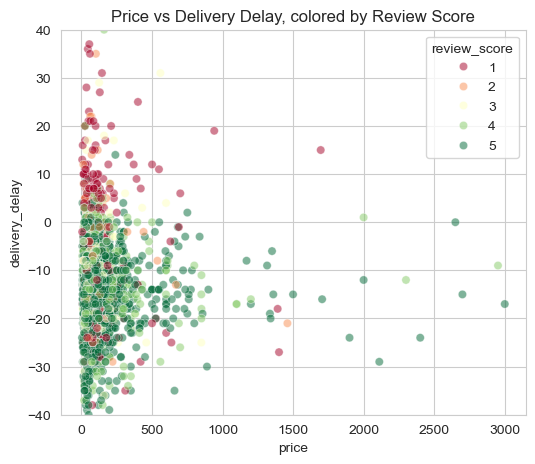

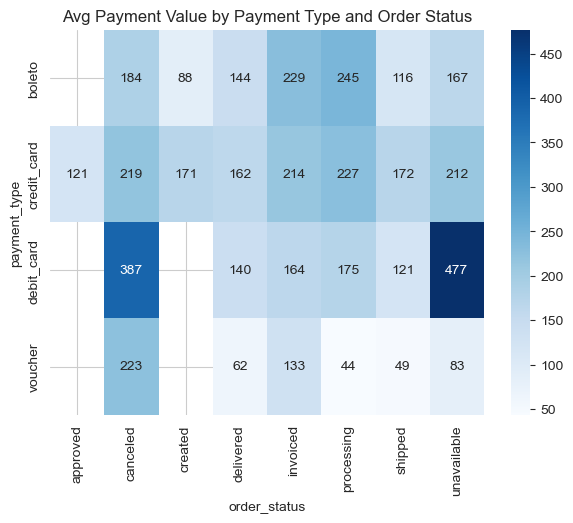

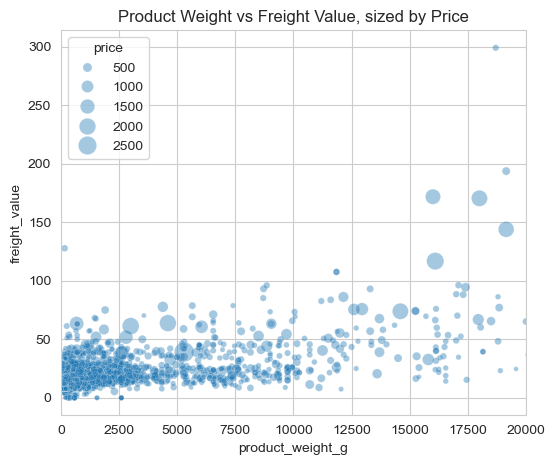

In [13]:
# 1. Price, freight, and delivery delay together, colored by review score
multi_df = pd.read_sql("""
    SELECT oi.price, oi.freight_value, r.review_score,
           o.order_delivered_customer_date, o.order_estimated_delivery_date
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    JOIN order_reviews r ON o.order_id = r.order_id
    WHERE o.order_delivered_customer_date IS NOT NULL
""", con=engine)

multi_df["order_delivered_customer_date"] = pd.to_datetime(multi_df["order_delivered_customer_date"])
multi_df["order_estimated_delivery_date"] = pd.to_datetime(multi_df["order_estimated_delivery_date"])
multi_df["delivery_delay"] = (multi_df["order_delivered_customer_date"] - multi_df["order_estimated_delivery_date"]).dt.days

sample = multi_df.sample(3000, random_state=1)
plt.figure(figsize=(6,5))
sns.scatterplot(data=sample, x="price", y="delivery_delay", hue="review_score", palette="RdYlGn", alpha=0.5)
plt.title("Price vs Delivery Delay, colored by Review Score")
plt.ylim(-40, 40)
plt.show()

# 2. Payment type x order status x avg payment value (grouped bar)
pivot_df = pd.read_sql("""
    SELECT p.payment_type, o.order_status, p.payment_value
    FROM order_payments p
    JOIN orders o ON p.order_id = o.order_id
""", con=engine)

pivot_table = pivot_df.groupby(["payment_type", "order_status"])["payment_value"].mean().unstack()
plt.figure(figsize=(7,5))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="Blues")
plt.title("Avg Payment Value by Payment Type and Order Status")
plt.show()

# 3. Product weight, price, and freight value relationship
prod_multi = pd.read_sql("""
    SELECT p.product_weight_g, oi.price, oi.freight_value
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    WHERE p.product_weight_g > 0
""", con=engine)

sample2 = prod_multi.sample(3000, random_state=1)
plt.figure(figsize=(6,5))
sns.scatterplot(data=sample2, x="product_weight_g", y="freight_value", size="price", alpha=0.4, sizes=(10,200))
plt.title("Product Weight vs Freight Value, sized by Price")
plt.xlim(0, 20000)
plt.show()

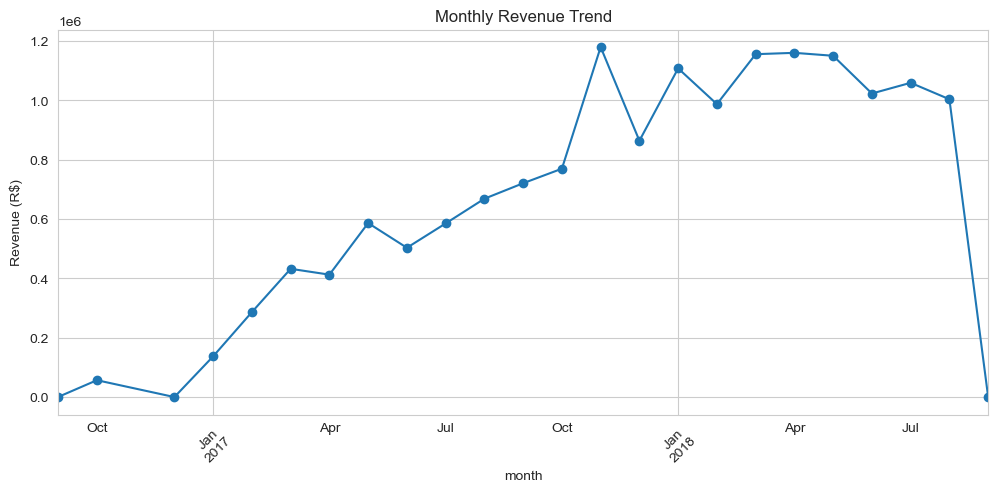

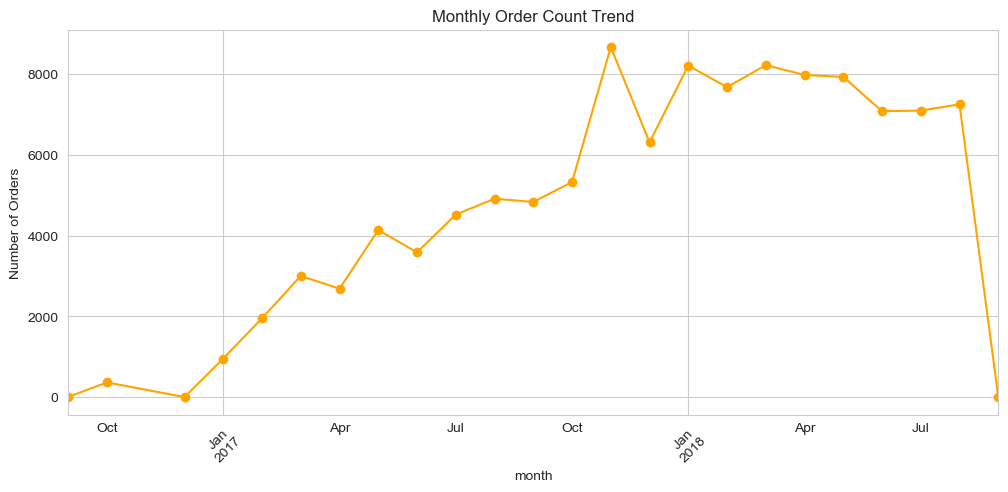

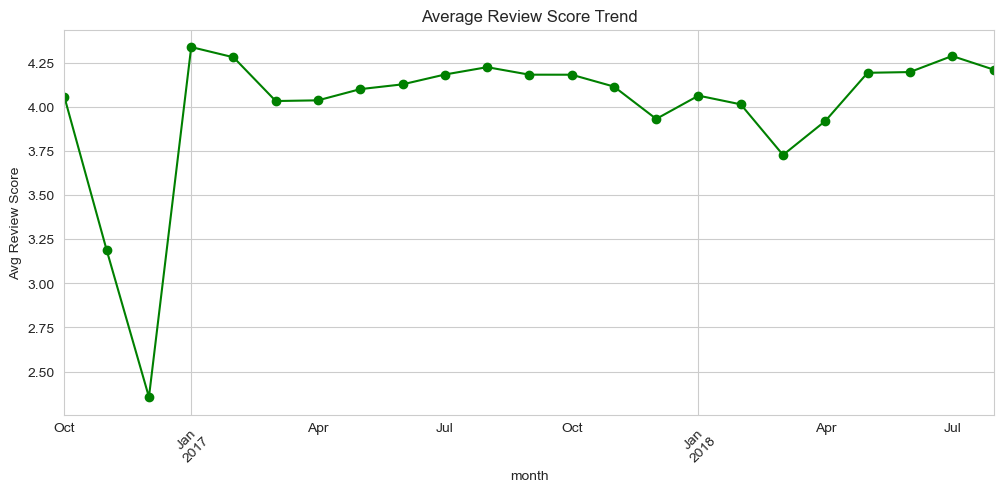

In [14]:
# 1. Monthly revenue trend
trend_df = pd.read_sql("""
    SELECT o.order_purchase_timestamp, oi.price, oi.freight_value
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
""", con=engine)

trend_df["order_purchase_timestamp"] = pd.to_datetime(trend_df["order_purchase_timestamp"])
trend_df["month"] = trend_df["order_purchase_timestamp"].dt.to_period("M")
trend_df["revenue"] = trend_df["price"] + trend_df["freight_value"]

monthly_revenue = trend_df.groupby("month")["revenue"].sum()
plt.figure(figsize=(12,5))
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (R$)")
plt.xticks(rotation=45)
plt.show()

# 2. Monthly order count trend
monthly_orders = trend_df.groupby("month")["order_purchase_timestamp"].count()
plt.figure(figsize=(12,5))
monthly_orders.plot(kind="line", marker="o", color="orange")
plt.title("Monthly Order Count Trend")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

# 3. Average review score trend over time
review_trend = pd.read_sql("""
    SELECT review_creation_date, review_score
    FROM order_reviews
""", con=engine)
review_trend["review_creation_date"] = pd.to_datetime(review_trend["review_creation_date"])
review_trend["month"] = review_trend["review_creation_date"].dt.to_period("M")

monthly_score = review_trend.groupby("month")["review_score"].mean()
plt.figure(figsize=(12,5))
monthly_score.plot(kind="line", marker="o", color="green")
plt.title("Average Review Score Trend")
plt.ylabel("Avg Review Score")
plt.xticks(rotation=45)
plt.show()

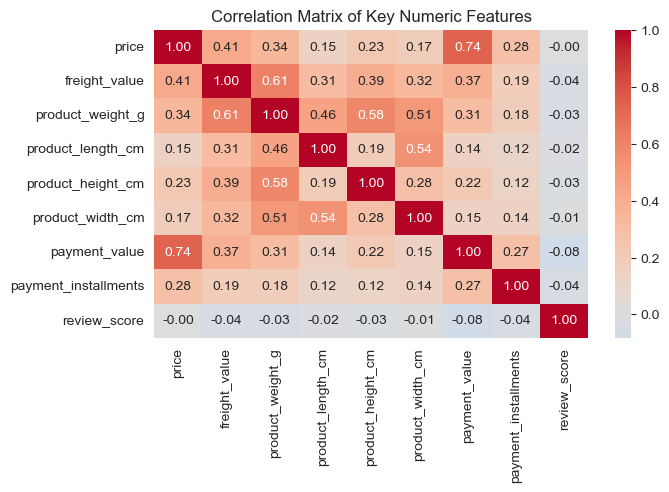

In [16]:
# Correlation matrix of key numeric features
corr_df = pd.read_sql("""
    SELECT oi.price, oi.freight_value, p.product_weight_g,
           p.product_length_cm, p.product_height_cm, p.product_width_cm,
           pay.payment_value, pay.payment_installments, r.review_score
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    JOIN order_payments pay ON oi.order_id = pay.order_id
    JOIN order_reviews r ON oi.order_id = r.order_id
""", con=engine)

plt.figure(figsize=(7,4))
corr_matrix = corr_df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Key Numeric Features")
plt.show()

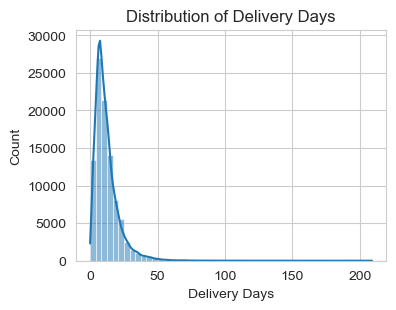

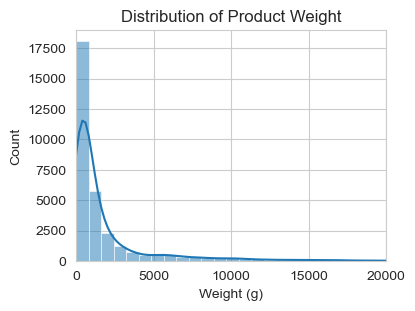

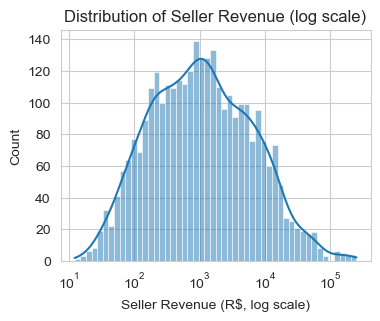

In [17]:
# 1. Delivery days distribution
delivery_df = pd.read_sql("""
    SELECT order_purchase_timestamp, order_delivered_customer_date
    FROM orders
    WHERE order_delivered_customer_date IS NOT NULL
""", con=engine)
delivery_df["order_purchase_timestamp"] = pd.to_datetime(delivery_df["order_purchase_timestamp"])
delivery_df["order_delivered_customer_date"] = pd.to_datetime(delivery_df["order_delivered_customer_date"])
delivery_df["delivery_days"] = (delivery_df["order_delivered_customer_date"] - delivery_df["order_purchase_timestamp"]).dt.days

plt.figure()
sns.histplot(delivery_df["delivery_days"], bins=50, kde=True)
plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.show()

# 2. Product weight distribution
weight_df = pd.read_sql("SELECT product_weight_g FROM products WHERE product_weight_g > 0", con=engine)
plt.figure()
sns.histplot(weight_df["product_weight_g"], bins=50, kde=True)
plt.title("Distribution of Product Weight")
plt.xlabel("Weight (g)")
plt.xlim(0, 20000)
plt.show()

# 3. Seller revenue distribution (log scale, since it's skewed)
plt.figure()
sns.histplot(seller_features["seller_revenue"], bins=50, kde=True, log_scale=True)
plt.title("Distribution of Seller Revenue (log scale)")
plt.xlabel("Seller Revenue (R$, log scale)")
plt.show()